# N-BEATS experiment - Walmart Store Sales Forecasting

Person B track (DL + Prophet).

**Library switch (this revision):** previously built on `darts.models.NBEATSModel`,
which scored Kaggle Public 4289.38 / Private 4524.03 - the worst of every
model in the project. Course feedback on the presentation was that Darts was
the wrong tool for TFT/N-BEATS and a neural-network-native forecasting
library should have been used instead - `model_experiment_tft.ipynb` already
made this switch to **Nixtla's `neuralforecast`**; this notebook applies the
same pattern to N-BEATS.

**Bigger change than a library swap: `NBEATSx`, not vanilla `NBEATS`.** The
old Darts N-BEATS run's own diagnostics (`README.md` SS4.5) identified its
worst flaw as architectural, not a bug: plain N-BEATS only ever sees **past**
values (`past-covariates-only`), so it has zero access to *future* calendar/
holiday timing and has to infer the whole holiday effect purely from history
- this is exactly why its Thanksgiving/Christmas peaks arrived a week *late*.
`neuralforecast` ships `NBEATSx`, an extension of the same stacked-residual
architecture that additionally accepts `hist_exog_list` / `futr_exog_list` /
`stat_exog_list` - the same future-covariate access `model_experiment_tft.ipynb`
already uses. This is expected to meaningfully close N-BEATS's gap to TFT,
though it is very unlikely to close the larger gap to Prophet/XGBoost - see
that gap's root cause below.

**Decisions this notebook records for the README:**
- future vs past covariate split, static covariate scope (`Type` one-hot +
  `Size` scaled), quantile loss (`MQLoss([0.1, 0.5, 0.9])`), and the
  `TRAIN_END`-alignment panel construction are all reused byte-for-byte from
  `model_experiment_tft.ipynb` - see that notebook for the reasoning behind
  each. Static covariates are a genuine addition versus the old Darts N-BEATS,
  which had no static-covariate support at all.
- **hard 2-hour training time budget**, enforced via PyTorch Lightning's
  built-in `max_time` (not just a step-count guess) on every fit below, so a
  slow or misconfigured runtime cannot silently run for hours - see the
  compute-budget section for the exact per-stage allocation. A previous run
  of the TFT notebook did exactly this (150+ minutes with nothing to show for
  it) because only `max_steps` was capped, with no wall-clock ceiling and no
  visible progress; both gaps are closed here from the start.
- **why this won't score below 3000 either:** WMAE weights holiday weeks 5x,
  and neither TFT nor N-BEATS(x) has an explicit holiday-effect term the way
  Prophet does - they still have to learn the holiday amplitude implicitly
  from a training signal that's mostly non-holiday weeks. Giving N-BEATSx
  future covariates fixes the *phase-shift* bug (peaks landing on the wrong
  week), not the *amplitude* gap to Prophet. Expect an improvement over the
  old 4289.38/4524.03, plausibly into TFT's ~3500-3700 range, not a jump to
  sub-3000.

**MLflow run plan** (under `NBEATS_Training`, same experiment as the Darts
runs so history stays comparable - each run additionally logs
`library="neuralforecast"`): `NBEATS_Feature_Selection`, three `NBEATS_HP_*`
architecture-comparison runs, up to three `NBEATS_CV_Fold*` runs, and
`NBEATS_Final`.


##  Init cell (Colab-compatible)

Byte-identical to the TFT notebook's init cell.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IS_COLAB:
    REPO_URL = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git"
    REPO_DIR = "/content/walmart-sales-forecasting"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r",
         f"{REPO_DIR}/requirements.txt", "--quiet"],
        check=True,
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "neuralforecast", "--quiet"], check=True)

    os.chdir(f"{REPO_DIR}/notebooks")

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    repo_data_dir = Path(REPO_DIR) / "data" / "raw"
    if drive_data_dir.exists():
        subprocess.run(["cp", "-r", f"{drive_data_dir}/.", str(repo_data_dir)], check=True)
    else:
        raise FileNotFoundError(
            f"Expected Drive data folder not found at {drive_data_dir}. "
            "Create it (or add it as a My Drive shortcut) before running this notebook."
        )

sys.path.append(str(Path.cwd().parent))


Mounted at /content/drive


##  Imports

In [2]:
import pickle
import tempfile
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.preprocessing import StandardScaler

import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss

from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import Callback

from src.preprocessing import load_raw_data, WalmartPreprocessor
from src.features import add_temporal_features
from src.evaluation import weighted_mae

pd.set_option("display.max_columns", 50)
pd.set_option("future.no_silent_downcasting", True)


###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already
set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).


In [3]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token


##  Load DagsHub credentials

`MLFLOW_TRACKING_USERNAME`/`MLFLOW_TRACKING_PASSWORD` are never hardcoded in
this notebook (it gets committed to the shared repo, so a hardcoded token
would leak).

- On the Colab UI: read from Colab secrets - add `DAGSHUB_USERNAME` and
  `DAGSHUB_TOKEN` via the key icon in the left sidebar, and enable
  "Notebook access" for both. Same approach as every other notebook.
- From VS Code / non-UI runtimes: use the manual-override cell above.
- Locally: falls back to a gitignored `.env` in the repo root.


In [4]:
if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided (e.g. by the manual-override cell above when driving the
    # Colab runtime from VS Code, where google.colab.userdata would time out).
    # Note: userdata.get(...) must NOT be evaluated in this case - it blocks for
    # ~minutes and raises when there is no Colab browser UI to answer it.
    creds_source = "pre-set environment variables"
elif IS_COLAB:
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
    creds_source = "Colab secrets (DAGSHUB_USERNAME / DAGSHUB_TOKEN)"
else:
    from dotenv import load_dotenv

    env_path = Path.cwd().parent / ".env"
    load_dotenv(env_path)
    creds_source = str(env_path)

assert os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"), (
    f"MLFLOW_TRACKING_USERNAME/PASSWORD not set (tried: {creds_source}). "
    "On the Colab UI: add DAGSHUB_USERNAME and DAGSHUB_TOKEN as Colab secrets "
    "(key icon in the left sidebar) and enable notebook access for both. "
    "From VS Code / non-UI runtimes: run the manual-override cell above. "
    "Locally: create a .env in the repo root with MLFLOW_TRACKING_USERNAME=... "
    "and MLFLOW_TRACKING_PASSWORD=..."
)
print("MLflow credentials loaded from:", creds_source)


MLflow credentials loaded from: pre-set environment variables


##  MLflow tracking store

Shared DagsHub MLflow server - the single source of truth for cross-model
WMAE comparison and the Model Registry, so all models log here rather than to
a per-notebook local store. Same experiment name as the previous Darts-based
runs (`NBEATS_Training`) so history stays comparable; each run below logs
`library="neuralforecast"` as a param to distinguish new runs from old ones.
Does not silently fall back to a local store if auth fails - that would
desync N-BEATS's runs from the rest of the team's.


In [5]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("NBEATS_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns or sqlite - that would desync from the rest of the team's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("NBEATS_Training").name)


MLflow tracking URI: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow
Active experiment: NBEATS_Training


##  Load, merge, clean

Reuses `load_raw_data` / `WalmartPreprocessor` rather than reimplementing
loading logic. `WalmartPreprocessor.fit()` loads and caches `features_` /
`stores_` internally - `stores_` (Store, Type, Size) is what the
static-covariate section below builds on.


In [6]:
raw_data = load_raw_data(data_dir="../data/raw")

train_raw = raw_data["train"]
test_raw = raw_data["test"]

preprocessor = WalmartPreprocessor(data_dir="../data/raw")
preprocessor.fit(train_raw)

train_clean = preprocessor.transform(train_raw)
test_clean = preprocessor.transform(test_raw)

train_feat = add_temporal_features(train_clean)
test_feat = add_temporal_features(test_clean)

print(train_feat.shape, test_feat.shape)
train_feat.head()


(421570, 23) (115064, 22)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,7,217,294,329
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,0,210,287,322
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,-7,203,280,315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010,-14,196,273,308
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010,-21,189,266,301


##  Covariate coverage decision

Same check already established in the DLinear/TFT notebooks - reused here
rather than re-derived, since it's a property of `features.csv`, not of the
model. A column only becomes a *future* covariate if it's non-null for every
week of the test horizon (2012-11-02 to 2013-07-26).


In [7]:
test_dates = pd.date_range("2012-11-02", "2013-07-26", freq="W-FRI")

macro_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
              "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

features_lookup = preprocessor.features_

coverage = {}
for col in macro_cols:
    non_null_dates = set(features_lookup.loc[features_lookup[col].notna(), "Date"])
    coverage[col] = set(test_dates).issubset(non_null_dates)

coverage_df = pd.Series(coverage, name="covers_full_test_range")
print(coverage_df)

calendar_future_cols = ["IsHoliday", "week_of_year", "month", "year",
                         "days_to_super_bowl", "days_to_labor_day",
                         "days_to_thanksgiving", "days_to_christmas"]

FUTURE_COVARIATE_COLS = calendar_future_cols + [c for c in coverage_df.index if coverage_df[c]]
PAST_COVARIATE_COLS = [c for c in coverage_df.index if not coverage_df[c]]
all_covariate_cols = FUTURE_COVARIATE_COLS + PAST_COVARIATE_COLS

print("Future covariates:", FUTURE_COVARIATE_COLS)
print("Past covariates:", PAST_COVARIATE_COLS)


Temperature      True
Fuel_Price       True
CPI              True
Unemployment     True
MarkDown1        True
MarkDown2       False
MarkDown3        True
MarkDown4        True
MarkDown5        True
Name: covers_full_test_range, dtype: bool
Future covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Past covariates: ['MarkDown2']


##  Static covariates (`Type` + `Size` only - see intro markdown for why)

`neuralforecast`'s `stat_exog_list` takes plain numeric columns, so `Type` is
one-hot encoded and `Size` is scaled with `StandardScaler` (fit on the store
table, which has no train/test split of its own). One static row is built per
`unique_id` (`"{Store}_{Dept}"`), covering every (Store, Dept) pair seen in
train **or** test, so the pipeline's `.predict()` never hits a missing
static-covariate lookup. The old Darts N-BEATS had no static-covariate
support at all - this is a genuine capability addition, not just a library
swap.


In [8]:
stores_df = preprocessor.stores_.copy()

type_dummies = pd.get_dummies(stores_df["Type"].astype(str), prefix="Type").astype(float)
TYPE_COLS = sorted(type_dummies.columns.tolist())

size_scaler = StandardScaler()
stores_df["Size_Scaled"] = size_scaler.fit_transform(stores_df[["Size"]]).astype(float)

stores_static = pd.concat([stores_df[["Store", "Size_Scaled"]], type_dummies], axis=1)
STATIC_COLS = TYPE_COLS + ["Size_Scaled"]

all_pairs = (
    pd.concat([train_feat[["Store", "Dept"]], test_feat[["Store", "Dept"]]])
    .drop_duplicates()
    .reset_index(drop=True)
)

static_df = all_pairs.merge(stores_static, on="Store", how="left")
static_df["unique_id"] = static_df["Store"].astype(str) + "_" + static_df["Dept"].astype(str)
static_df = static_df[["unique_id"] + STATIC_COLS]

print("Static covariates:", STATIC_COLS)
print(f"static_df: {static_df.shape[0]} (Store, Dept) series")
static_df.head()


Static covariates: ['Type_A', 'Type_B', 'Type_C', 'Size_Scaled']
static_df: 3342 (Store, Dept) series


,unique_id,Type_A,Type_B,Type_C,Size_Scaled
0,1_1,1.0,0.0,0.0,0.333175
1,1_2,1.0,0.0,0.0,0.333175
2,1_3,1.0,0.0,0.0,0.333175
3,1_4,1.0,0.0,0.0,0.333175
4,1_5,1.0,0.0,0.0,0.333175


##  Model constants and compute budget

**Hard 2-hour training time budget**, enforced via PyTorch Lightning's
built-in `max_time` on every fit below - not just a `max_steps` guess. This
is a hard requirement (not a nice-to-have): a previous run of the TFT
notebook trained on CPU for 150+ minutes with zero visible progress because
only `max_steps` was set, with no wall-clock ceiling and the progress bar
disabled. Both gaps are closed here:

- **`max_time`** per stage (`HP_MAX_TIME_MINUTES` / `CV_MAX_TIME_MINUTES` /
  `FINAL_MAX_TIME_MINUTES`) stops that fit at a wall-clock deadline regardless
  of how many steps it reached - a real safety net against slow/misconfigured
  runtimes, independent of any throughput assumption.
- **`max_steps`** is still set too (as a generous ceiling) so a fast GPU
  doesn't train forever *within* the time budget for no reason - whichever
  limit is hit first wins.
- Worst-case total across every stage below (3 HP candidates + 3 CV folds +
  1 Final fit, every one hitting its `max_time` ceiling) is
  {hp}+{cv}+{final} = 86 minutes of training, leaving >30 minutes of the
  2-hour budget for data loading, panel construction, diagnostics, and
  submission generation - see the constants cell for the exact numbers.
- **GPU check is a hard failure, not just a print** (same as the TFT
  notebook): selecting "T4 GPU" in Colab's Runtime > Change runtime type does
  NOT attach a GPU to a session that's already running - if on Colab without
  a GPU actually attached, the cell below raises immediately with reconnect
  instructions.
- **Progress is visible**: `enable_progress_bar=True` plus a custom
  `PercentProgressCallback` prints `step X/Y - Z% (bound by step/time budget)
  - elapsed Ns, ~W min remaining` every 10% of whichever limit (steps or
  time) is closer - training is never a silent black box.

`h` (forecast horizon) is fixed per model at construction time - CV/HP models
use `h=VAL_WEEKS` (13, matching every other model's fold convention), the
Final model uses `h=HORIZON` (39, the full test horizon).


In [9]:
FREQ = "W-FRI"
inferred_freq = pd.infer_freq(sorted(train_feat["Date"].unique()))
print("Inferred frequency from data:", inferred_freq)
assert inferred_freq in ("W-FRI", None), f"Unexpected frequency: {inferred_freq}"

INPUT_SIZE = 52   # one year of history
HORIZON = 39      # covers the full test horizon - test is ~39 weeks past train
VAL_WEEKS = 13    # CV fold validation window - same convention as every other model

QUANTILES = [0.1, 0.5, 0.9]

GPU_AVAILABLE = torch.cuda.is_available()
print("=" * 60)
print("GPU available:", GPU_AVAILABLE)
print("=" * 60)

if IS_COLAB and not GPU_AVAILABLE:
    raise RuntimeError(
        "Running on Colab but no GPU is attached to THIS runtime session - "
        "training would silently fall back to CPU, and what should take "
        "well under the 2-hour budget could instead blow through it with "
        "nothing to show for it (this already happened once on the TFT "
        "notebook: a run went 150+ minutes on CPU because of exactly this). "
        "Selecting 'T4 GPU' in Runtime > Change runtime type does NOT attach "
        "a GPU to a session that's already running - go to Runtime > "
        "Disconnect and delete runtime, then reconnect (or Runtime > Run all "
        "from a fresh state) so it actually starts on a GPU instance. "
        "Re-run this cell after reconnecting and confirm it prints "
        "'GPU available: True' before continuing."
    )

# Hard wall-clock ceilings (enforced via pl.Trainer's max_time - see markdown above).
# Worst case: 5*3 (HP) + 12*3 (CV) + 35 (Final) = 86 min of training,
# leaving >30 min of the 2-hour budget for everything else in the notebook.
HP_MAX_TIME_MINUTES = 5
CV_MAX_TIME_MINUTES = 12
FINAL_MAX_TIME_MINUTES = 35

# Generous step ceilings - only bind if the GPU is fast enough to reach them
# before the time budget above does; otherwise max_time wins first.
HP_MAX_STEPS = 500
CV_MAX_STEPS = 2500
FINAL_MAX_STEPS = 10000

BATCH_SIZE_SEARCH = 512  # HP search + CV folds
BATCH_SIZE_FINAL = 1024


class PercentProgressCallback(Callback):
    """Prints plain-text 'step X/Y - Z% (bound by step/time budget) - elapsed
    Ns, ~W min remaining' progress at regular intervals - a guaranteed-visible
    supplement to the trainer's own progress bar, since that bar can render
    oddly or get lost in scrolled/captured notebook output. Tracks progress
    against BOTH the step ceiling and the max_time ceiling (whichever is
    closer to being hit), since either one can end training first.
    """

    def __init__(self, max_time_seconds=None, print_every_pct=10):
        self.max_time_seconds = max_time_seconds
        self.print_every_pct = print_every_pct
        self._last_pct = -1
        self._t0 = None

    def on_train_start(self, trainer, pl_module):
        self._t0 = time.time()
        self._last_pct = -1

    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        max_steps = trainer.max_steps
        elapsed = time.time() - self._t0
        step = trainer.global_step

        step_pct = (100 * step / max_steps) if max_steps and max_steps > 0 else 0
        time_pct = (100 * elapsed / self.max_time_seconds) if self.max_time_seconds else 0
        pct = int(max(step_pct, time_pct))

        if pct >= self._last_pct + self.print_every_pct:
            self._last_pct = pct
            rate = step / elapsed if elapsed > 0 else 0
            steps_remaining_min = (max_steps - step) / rate / 60 if (rate > 0 and max_steps) else float("inf")
            time_remaining_min = (self.max_time_seconds - elapsed) / 60 if self.max_time_seconds else float("inf")
            remaining_min = min(steps_remaining_min, time_remaining_min)
            bound_by = "step budget" if steps_remaining_min <= time_remaining_min else "time budget"
            print(f"[NBEATSx] step {step}/{max_steps} - {pct}% (bound by {bound_by}) - elapsed {elapsed:.0f}s, ~{remaining_min:.1f} min remaining")


def make_trainer_kwargs(logger=None, max_time_minutes=None):
    """Keyword args forwarded through NBEATSx's **trainer_kwargs to the
    underlying pl.Trainer, so GPU selection and the time budget are
    consistent everywhere below."""
    max_time_seconds = max_time_minutes * 60 if max_time_minutes is not None else None
    kwargs = {
        "accelerator": "gpu" if GPU_AVAILABLE else "cpu",
        "enable_progress_bar": True,
        "callbacks": [PercentProgressCallback(max_time_seconds=max_time_seconds)],
    }
    if logger is not None:
        kwargs["logger"] = logger
    if GPU_AVAILABLE:
        kwargs["devices"] = 1
    if max_time_minutes is not None:
        kwargs["max_time"] = timedelta(minutes=max_time_minutes)
    return kwargs


def median_column(preds: pd.DataFrame) -> str:
    """Name of the median-quantile column in a neuralforecast predict() output -
    looked up by suffix rather than hardcoded, since it depends on the model's alias."""
    candidates = [c for c in preds.columns if c.endswith("-median")]
    assert len(candidates) == 1, f"Expected exactly one '-median' column, got {candidates}"
    return candidates[0]


def latest_metrics_csv(csv_logger) -> str:
    """Path to the metrics.csv actually written by this CSVLogger.

    `csv_logger.log_dir` is unreliable to read AFTER fit() - it's a lazily
    recomputed 'next available version' property, and can report a version
    one higher than what Trainer actually wrote. Glob for the real thing instead.
    """
    version_dirs = sorted(
        Path(csv_logger.save_dir, csv_logger.name).glob("version_*"),
        key=lambda p: int(p.name.split("_")[1]),
    )
    if not version_dirs:
        raise FileNotFoundError(f"No version_* dir under {csv_logger.save_dir}/{csv_logger.name}")
    return str(version_dirs[-1] / "metrics.csv")


print("Columns fed as hist_exog_list (past covariates):", PAST_COVARIATE_COLS)
print("Columns fed as futr_exog_list (future covariates):", FUTURE_COVARIATE_COLS)
print("Columns fed as stat_exog_list (static covariates):", STATIC_COLS)


Inferred frequency from data: W-FRI
GPU available: True
Columns fed as hist_exog_list (past covariates): ['MarkDown2']
Columns fed as futr_exog_list (future covariates): ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Columns fed as stat_exog_list (static covariates): ['Type_A', 'Type_B', 'Type_C', 'Size_Scaled']


##  Build the long-format panel (gap-interpolated target, scaled covariates)

Byte-for-byte the same panel construction as `model_experiment_tft.ipynb`,
including the `TRAIN_END`-alignment fix (every series reindexed through the
same shared train-cutoff date, not its own last observed date - see that
notebook's markdown for why this matters: a discontinued department would
otherwise misalign `nf.predict()`'s forecast window for every series). Numeric
covariates are scaled with `StandardScaler` fit on train dates only;
`IsHoliday` is deliberately excluded from scaling (stays a raw 0/1 flag, since
`weighted_mae` and every holiday diagnostic below matches against literal
`True`/`False`). The target `y` is not manually scaled -
`NBEATSx(scaler_type="robust")` normalizes/denormalizes each series
internally, keyed by `unique_id` identity.


In [10]:
def build_covariate_lookup(full_df, covariate_cols, global_start, global_end, freq=FREQ):
    """One row per (Store, Date) covariate snapshot, ffill/bfill'd per store,
    spanning the full global range so it always covers any forecast horizon."""
    store_level = full_df.drop_duplicates(subset=["Store", "Date"])[["Store", "Date"] + covariate_cols]
    full_range = pd.date_range(global_start, global_end, freq=freq)
    filled = []
    for store, g in store_level.groupby("Store"):
        g = g.sort_values("Date").set_index("Date").reindex(full_range)
        g.index.name = "Date"
        g[covariate_cols] = g[covariate_cols].ffill().bfill()
        g["Store"] = store
        filled.append(g.reset_index())
    lookup = pd.concat(filled, ignore_index=True)
    return lookup.rename(columns={"Date": "ds"})


def build_target_long(df, global_end, freq=FREQ):
    """Long (unique_id, ds, y, Store, Dept) frame, one row per (Store, Dept, Date).

    Every series is reindexed through the SAME global_end date (each series keeps
    its own natural start), not its own last observed date - see intro markdown
    for why (a discontinued department would otherwise misalign nf.predict()'s
    forecast window). Any trailing gap this creates is linearly interpolated
    same as interior gaps - interpolate(limit_direction="both") holds the last
    known value flat when there's no later real point to interpolate towards.
    """
    rows = []
    for (store, dept), g in df.groupby(["Store", "Dept"]):
        g = g.sort_values("Date")
        full_range = pd.date_range(g["Date"].min(), global_end, freq=freq)
        y = g.set_index("Date")["Weekly_Sales"].reindex(full_range)
        y = y.interpolate(method="linear", limit_direction="both")
        rows.append(pd.DataFrame({
            "unique_id": f"{store}_{dept}",
            "ds": full_range,
            "y": y.values,
            "Store": store,
            "Dept": dept,
        }))
    return pd.concat(rows, ignore_index=True)


numeric_cols = [c for c in all_covariate_cols if c != "IsHoliday"]  # IsHoliday stays a raw 0/1 flag - see markdown above
full_feat_df = pd.concat([train_feat, test_feat], ignore_index=True).drop_duplicates(
    subset=["Store", "Dept", "Date"]
)
df_scaler = StandardScaler()
train_dates = train_feat["Date"].unique()
df_scaler.fit(full_feat_df.loc[full_feat_df["Date"].isin(train_dates), numeric_cols])
full_feat_scaled_df = full_feat_df.copy()
full_feat_scaled_df[numeric_cols] = df_scaler.transform(full_feat_df[numeric_cols])

GLOBAL_START = full_feat_scaled_df["Date"].min()
GLOBAL_END = full_feat_scaled_df["Date"].max()
print(f"Covariates span {GLOBAL_START} -> {GLOBAL_END}")

covariate_lookup = build_covariate_lookup(full_feat_scaled_df, all_covariate_cols, GLOBAL_START, GLOBAL_END)

TRAIN_END = train_feat["Date"].max()
target_long = build_target_long(train_feat, global_end=TRAIN_END)

panel_df = target_long.merge(covariate_lookup, on=["Store", "ds"], how="left")
n_nan_cov = panel_df[all_covariate_cols].isna().sum().sum()
assert n_nan_cov == 0, f"panel_df: {n_nan_cov} NaN covariate values after merge - stop"

print(f"Built panel_df: {panel_df.shape[0]} rows, {panel_df['unique_id'].nunique()} (Store, Dept) series")
panel_df.head()


Covariates span 2010-02-05 00:00:00 -> 2013-07-26 00:00:00
Built panel_df: 462053 rows, 3331 (Store, Dept) series


,unique_id,ds,y,Store,Dept,IsHoliday,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown3,MarkDown4,MarkDown5,MarkDown2
0,1_1,2010-02-05,24924.50,1,1,False,-1.471661,-1.371945,-1.215487,1.471661,1.471661,1.471661,1.471661,-0.963798,-1.720834,1.018774,0.078201,-0.427943,-0.084662,-0.278117,-0.395181,-0.173069
1,1_1,2010-02-12,46039.49,1,1,True,-1.400999,-1.371945,-1.215487,1.400999,1.400999,1.400999,1.400999,-1.169783,-1.773177,1.022498,0.078201,-0.427943,-0.084662,-0.278117,-0.395181,-0.173069
2,1_1,2010-02-19,41595.55,1,1,False,-1.330337,-1.371945,-1.215487,1.330337,1.330337,1.330337,1.330337,-1.092810,-1.847330,1.023697,0.078201,-0.427943,-0.084662,-0.278117,-0.395181,-0.173069
3,1_1,2010-02-26,19403.54,1,1,False,-1.259675,-1.371945,-1.215487,1.259675,1.259675,1.259675,1.259675,-0.729625,-1.744825,1.024476,0.078201,-0.427943,-0.084662,-0.278117,-0.395181,-0.173069
4,1_1,2010-03-05,21827.90,1,1,False,-1.189013,-1.063609,-1.215487,1.189013,1.189013,1.189013,1.189013,-0.736672,-1.605243,1.025255,0.078201,-0.427943,-0.084662,-0.278117,-0.395181,-0.173069


## Time-based CV: expanding-window splits

Uses the real shared `src/validation.py` splitter (`expanding_window_splits`)
- same one every other model in the project uses. 3 folds, same as TFT -
each fold's `max_time` ceiling (see compute-budget cell above) keeps this
within the overall 2-hour budget regardless of throughput.


In [11]:
from src.validation import expanding_window_splits, describe_split

N_SPLITS = 3
MIN_TRAIN_WEEKS = 52

splits = expanding_window_splits(
    train_feat["Date"], n_splits=N_SPLITS, val_weeks=VAL_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS
)
assert len(splits) == N_SPLITS, "history too short for the requested number of folds"

for i, split in enumerate(splits):
    print(f"fold {i}:", describe_split(split))


fold 0: {'train_start': 'start_of_history', 'train_end': '2012-01-27 00:00:00', 'val_start': '2012-02-03 00:00:00', 'val_end': '2012-04-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}
fold 1: {'train_start': 'start_of_history', 'train_end': '2012-04-27 00:00:00', 'val_start': '2012-05-04 00:00:00', 'val_end': '2012-07-27 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 0}
fold 2: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}


##  Log covariate/static-covariate decisions (`NBEATS_Feature_Selection`)

Lightweight run - just records the covariate split, static-covariate scope,
and library choice as params. No model fit happens here (actual training
happens in the HP-search, CV, and Final stages below).


In [12]:
with mlflow.start_run(run_name="NBEATS_Feature_Selection"):
    mlflow.log_params({
        "library": "neuralforecast",
        "model": "NBEATSx",
        "future_covariates": ",".join(FUTURE_COVARIATE_COLS) if FUTURE_COVARIATE_COLS else "none",
        "past_covariates": ",".join(PAST_COVARIATE_COLS),
        "static_covariates": ",".join(STATIC_COLS),
        "static_covariate_scope": "Type (one-hot) + Size (scaled) - new vs old Darts N-BEATS (had none)",
        "likelihood": f"MQLoss({QUANTILES})",
        "scaling": "StandardScaler (covariates only, fit on train) + NBEATSx(scaler_type='robust') for the target internally, per-series by unique_id",
        "target_gap_fill": "linear_interpolation (interior gaps only - genuine 0-sales weeks are untouched)",
        "covariate_gap_fill": "ffill/bfill, built once per Store (covariates are Dept-invariant)",
        "n_series_total": panel_df["unique_id"].nunique(),
        "input_size": INPUT_SIZE,
        "horizon_cv": VAL_WEEKS,
        "horizon_final": HORIZON,
        "start_padding_enabled": True,
        "hp_max_time_minutes": HP_MAX_TIME_MINUTES,
        "cv_max_time_minutes": CV_MAX_TIME_MINUTES,
        "final_max_time_minutes": FINAL_MAX_TIME_MINUTES,
    })

print("Logged NBEATS_Feature_Selection.")


🏃 View run NBEATS_Feature_Selection at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2/runs/92b3af156e854c14a95163b9d7b5b2a9
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2
Logged NBEATS_Feature_Selection.


##  Shared helper: build one CV fold's frames

Used by both the hyperparameter comparison below and the full CV loop, so
the exact same fold-construction logic backs both.


In [13]:
def split_long(panel, split):
    """Apply a Split (src/validation.py) to the long panel_df. Returns (train_long, val_long)."""
    train_mask = panel["ds"] <= split.train_end
    if split.train_start is not None:
        train_mask &= panel["ds"] >= split.train_start
    val_mask = (panel["ds"] >= split.val_start) & (panel["ds"] <= split.val_end)
    return panel.loc[train_mask].copy(), panel.loc[val_mask].copy()


def fit_predict_fold(split, max_steps, max_time_minutes, batch_size,
                      stack_types=("identity", "trend", "seasonality"),
                      n_blocks=(1, 1, 1), mlp_units=None, logger=None):
    """Fit a fresh NBEATSx on one fold's train frame, forecast its val window, and
    return (wmae, mae, scored_df, elapsed_seconds). Never reuses a model object
    whose .fit() already ran - a fresh NBEATSx/NeuralForecast is built every call."""
    fold_train, fold_val = split_long(panel_df, split)

    futr_df = fold_val[["unique_id", "ds"] + FUTURE_COVARIATE_COLS].copy()
    mlp_units = mlp_units or [[256, 256]] * len(stack_types)

    t0 = time.time()
    model = NBEATSx(
        h=VAL_WEEKS,
        input_size=INPUT_SIZE,
        stat_exog_list=STATIC_COLS,
        hist_exog_list=PAST_COVARIATE_COLS,
        futr_exog_list=FUTURE_COVARIATE_COLS,
        loss=MQLoss(quantiles=QUANTILES),
        max_steps=max_steps,
        batch_size=batch_size,
        stack_types=list(stack_types),
        n_blocks=list(n_blocks),
        mlp_units=mlp_units,
        scaler_type="robust",
        random_seed=42,
        start_padding_enabled=True,
        **make_trainer_kwargs(logger=logger, max_time_minutes=max_time_minutes),
    )
    nf = NeuralForecast(models=[model], freq=FREQ)
    nf.fit(
        df=fold_train[["unique_id", "ds", "y"] + PAST_COVARIATE_COLS + FUTURE_COVARIATE_COLS],
        static_df=static_df,
    )
    preds = nf.predict(futr_df=futr_df)
    elapsed = time.time() - t0

    med_col = median_column(preds)
    scored = preds.merge(
        fold_val[["unique_id", "ds", "y", "Store", "Dept", "IsHoliday"]],
        on=["unique_id", "ds"], how="inner",
    )
    scored = scored.rename(columns={med_col: "Weekly_Sales_Pred", "y": "Weekly_Sales"})

    wmae = weighted_mae(scored["Weekly_Sales"].values, scored["Weekly_Sales_Pred"].values, scored["IsHoliday"].values)
    mae = float(np.mean(np.abs(scored["Weekly_Sales"].values - scored["Weekly_Sales_Pred"].values)))
    return wmae, mae, scored, elapsed, nf


##  Hyperparameter comparison (`NBEATS_HP_Baseline` / `NBEATS_HP_Wide` / `NBEATS_HP_Deep`)

A quick, tight-time-budget comparison of three architecture sizes on the most
recent CV fold (`splits[-1]`, the fold closest to the final fit's actual
history), to pick a configuration before committing to the full CV below.
Each candidate gets its own MLflow run so the comparison is inspectable
run-by-run in the DagsHub UI, not just as a printed table.


In [14]:
HP_CONFIGS = [
    {"name": "Baseline", "stack_types": ("identity", "trend", "seasonality"), "n_blocks": (1, 1, 1), "mlp_units": [[256, 256]] * 3},
    {"name": "Wide", "stack_types": ("identity", "trend", "seasonality"), "n_blocks": (1, 1, 1), "mlp_units": [[512, 512]] * 3},
    {"name": "Deep", "stack_types": ("identity", "trend", "seasonality"), "n_blocks": (2, 2, 2), "mlp_units": [[256, 256]] * 3},
]

hp_split = splits[-1]
hp_results = []

for cfg in HP_CONFIGS:
    cfg_kwargs = {k: v for k, v in cfg.items() if k != "name"}
    with mlflow.start_run(run_name=f"NBEATS_HP_{cfg['name']}"):
        mlflow.log_params({
            "library": "neuralforecast",
            "hp_candidate": cfg["name"],
            "max_steps": HP_MAX_STEPS,
            "max_time_minutes": HP_MAX_TIME_MINUTES,
            "batch_size": BATCH_SIZE_SEARCH,
            "fold": describe_split(hp_split),
            "input_size": INPUT_SIZE,
            "h": VAL_WEEKS,
            "stack_types": str(cfg["stack_types"]),
            "n_blocks": str(cfg["n_blocks"]),
            "mlp_units": str(cfg["mlp_units"]),
        })

        wmae_hp, mae_hp, _, elapsed_hp, _ = fit_predict_fold(
            hp_split, max_steps=HP_MAX_STEPS, max_time_minutes=HP_MAX_TIME_MINUTES,
            batch_size=BATCH_SIZE_SEARCH, **cfg_kwargs
        )
        mlflow.log_metric("wmae", wmae_hp)
        mlflow.log_metric("mae", mae_hp)
        mlflow.log_metric("fit_predict_seconds", elapsed_hp)

    hp_results.append({"name": cfg["name"], "wmae": wmae_hp, "mae": mae_hp, "seconds": elapsed_hp, **cfg_kwargs})
    print(f"{cfg['name']}: WMAE={wmae_hp:.2f}  MAE={mae_hp:.2f}  ({elapsed_hp:.1f}s)")

hp_results_df = pd.DataFrame(hp_results).sort_values("wmae")
print(hp_results_df[["name", "wmae", "mae", "seconds"]])

BEST_HP = hp_results_df.iloc[0].to_dict()
BEST_HP_KWARGS = {
    "stack_types": BEST_HP["stack_types"],
    "n_blocks": BEST_HP["n_blocks"],
    "mlp_units": BEST_HP["mlp_units"],
}
print("Selected architecture for CV/Final:", BEST_HP["name"], BEST_HP_KWARGS)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 1.5 M  | train
--------------------------------------------------------------
1.5 M     Trainable params
1.8 K     Non-trainable params
1.5 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

[NBEATSx] step 45/500 - 9% (bound by step budget) - elapsed 2s, ~0.4 min remaining
[NBEATSx] step 95/500 - 19% (bound by step budget) - elapsed 3s, ~0.2 min remaining


...

[NBEATSx] step 445/500 - 89% (bound by step budget) - elapsed 14s, ~0.0 min remaining
[NBEATSx] step 495/500 - 99% (bound by step budget) - elapsed 15s, ~0.0 min remaining


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
/usr/local/lib/python3.12/dist-packages/neuralforecast/core.py:1222: UserWarning: Dropped 74 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
INFO:pytorch_lightning.utilities.rank_zero:Ignoring `Trainer(max_time=...)`, callbacks list already contains a Timer.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecate

Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_HP_Deep at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2/runs/885ead2d6a384c37b57c1fb7cef071a9
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2
Deep: WMAE=4422.51  MAE=4798.79  (17.3s)
       name         wmae          mae    seconds
1      Wide  2468.627396  2427.023667  15.909810
0  Baseline  3384.086848  3571.358175  19.868627
2      Deep  4422.514585  4798.794570  17.291166
Selected architecture for CV/Final: Wide {'stack_types': ('identity', 'trend', 'seasonality'), 'n_blocks': (1, 1, 1), 'mlp_units': [[512, 512], [512, 512], [512, 512]]}


##  Multi-fold expanding-window CV (`NBEATS_CV_Fold0` / `NBEATS_CV_Fold1` / `NBEATS_CV_Fold2`)

Refits a fresh NBEATSx per fold with `BEST_HP_KWARGS` from the search above,
forecasts the fold's 13-week validation window, and scores with the
competition's `weighted_mae`. Each fold is logged as its own MLflow run
(rather than one run with three metrics) so all folds are individually
inspectable, and a per-fold training-loss curve (via `CSVLogger`) is logged
as an artifact on each. **Wall-clock time is printed and logged per fold**,
bounded by `CV_MAX_TIME_MINUTES` regardless of throughput.


In [15]:
fold_results = []
scored_folds = []

for i, split in enumerate(splits):
    csv_logger = CSVLogger(save_dir="../submissions/_nbeats_logs", name=f"cv_fold_{i}")

    with mlflow.start_run(run_name=f"NBEATS_CV_Fold{i}"):
        mlflow.log_params({
            "library": "neuralforecast",
            "cv_strategy": "expanding_window",
            "fold_index": i,
            "n_splits": N_SPLITS,
            "val_weeks": VAL_WEEKS,
            "min_train_weeks": MIN_TRAIN_WEEKS,
            "max_steps": CV_MAX_STEPS,
            "max_time_minutes": CV_MAX_TIME_MINUTES,
            "batch_size": BATCH_SIZE_SEARCH,
            "input_size": INPUT_SIZE,
            "future_covariates": ",".join(FUTURE_COVARIATE_COLS) if FUTURE_COVARIATE_COLS else "none",
            "past_covariates": ",".join(PAST_COVARIATE_COLS),
            "stack_types": str(BEST_HP_KWARGS["stack_types"]),
            "n_blocks": str(BEST_HP_KWARGS["n_blocks"]),
            **describe_split(split),
        })

        wmae_fold, mae_fold, scored_fold, elapsed_fold, _ = fit_predict_fold(
            split, max_steps=CV_MAX_STEPS, max_time_minutes=CV_MAX_TIME_MINUTES,
            batch_size=BATCH_SIZE_SEARCH, logger=csv_logger, **BEST_HP_KWARGS
        )
        scored_fold["fold"] = i

        mlflow.log_metric("wmae", wmae_fold)
        mlflow.log_metric("mae", mae_fold)
        mlflow.log_metric("fit_predict_seconds", elapsed_fold)

        try:
            loss_history = pd.read_csv(latest_metrics_csv(csv_logger))
            loss_col = "train_loss_epoch" if "train_loss_epoch" in loss_history else "train_loss"
            loss_plot_path = f"../submissions/_nbeats_train_loss_fold{i}.png"
            plt.figure(figsize=(6, 4))
            loss_curve = loss_history.dropna(subset=[loss_col]) if loss_col in loss_history else None
            if loss_curve is not None and not loss_curve.empty:
                plt.plot(loss_curve["step"], loss_curve[loss_col], marker="o")
            plt.title(f"NBEATSx CV Fold {i} - training loss")
            plt.xlabel("Step")
            plt.ylabel("Train loss")
            plt.tight_layout()
            plt.savefig(loss_plot_path, dpi=120)
            plt.close()
            mlflow.log_artifact(loss_plot_path)
        except Exception as e:
            print(f"fold {i}: could not read/plot loss history ({e})")

    fold_results.append({**describe_split(split), "wmae": wmae_fold, "mae": mae_fold, "seconds": elapsed_fold})
    scored_folds.append(scored_fold)
    print(f"fold {i}: WMAE={wmae_fold:.2f}  MAE={mae_fold:.2f}  ({elapsed_fold:.1f}s)")

wmae_mean = float(np.mean([r["wmae"] for r in fold_results]))
wmae_std = float(np.std([r["wmae"] for r in fold_results]))
mae_mean = float(np.mean([r["mae"] for r in fold_results]))

scored = pd.concat(scored_folds, ignore_index=True)
print(f"\nCV WMAE: {wmae_mean:.2f} (+/- {wmae_std:.2f})")
print(f"CV MAE:  {mae_mean:.2f}")
print(f"Total CV wall-clock time: {sum(r['seconds'] for r in fold_results):.1f}s across {len(fold_results)} fold(s)")


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 4.2 M  | train
--------------------------------------------------------------
4.2 M     Trainable params
1.8 K     Non-trainable params
4.2 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

[NBEATSx] step 2475/2500 - 99% (bound by step budget) - elapsed 68s, ~0.0 min remaining


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2500` reached.
/usr/local/lib/python3.12/dist-packages/neuralforecast/core.py:1222: UserWarning: Dropped 74 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
INFO:pytorch_lightning.utilities.rank_zero:Ignoring `Trainer(max_time=...)`, callbacks list already contains a Timer.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecat

Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_CV_Fold2 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2/runs/f8bacafec2db4a97bf74da39d6a588fb
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2
fold 2: WMAE=2293.18  MAE=2267.53  (70.5s)

CV WMAE: 2093.85 (+/- 343.27)
CV MAE:  2069.04
Total CV wall-clock time: 207.1s across 3 fold(s)


##  Diagnostics

Aggregate actual vs predicted, error distribution, holiday vs non-holiday
WMAE split, per-series WMAE, and WMAE broken down by store `Type` - a direct
readout of whether the (new, vs old Darts N-BEATS) static-covariate encoder
is picking up store-level differences. Pools predictions across all CV folds
(`scored` from the cell above).


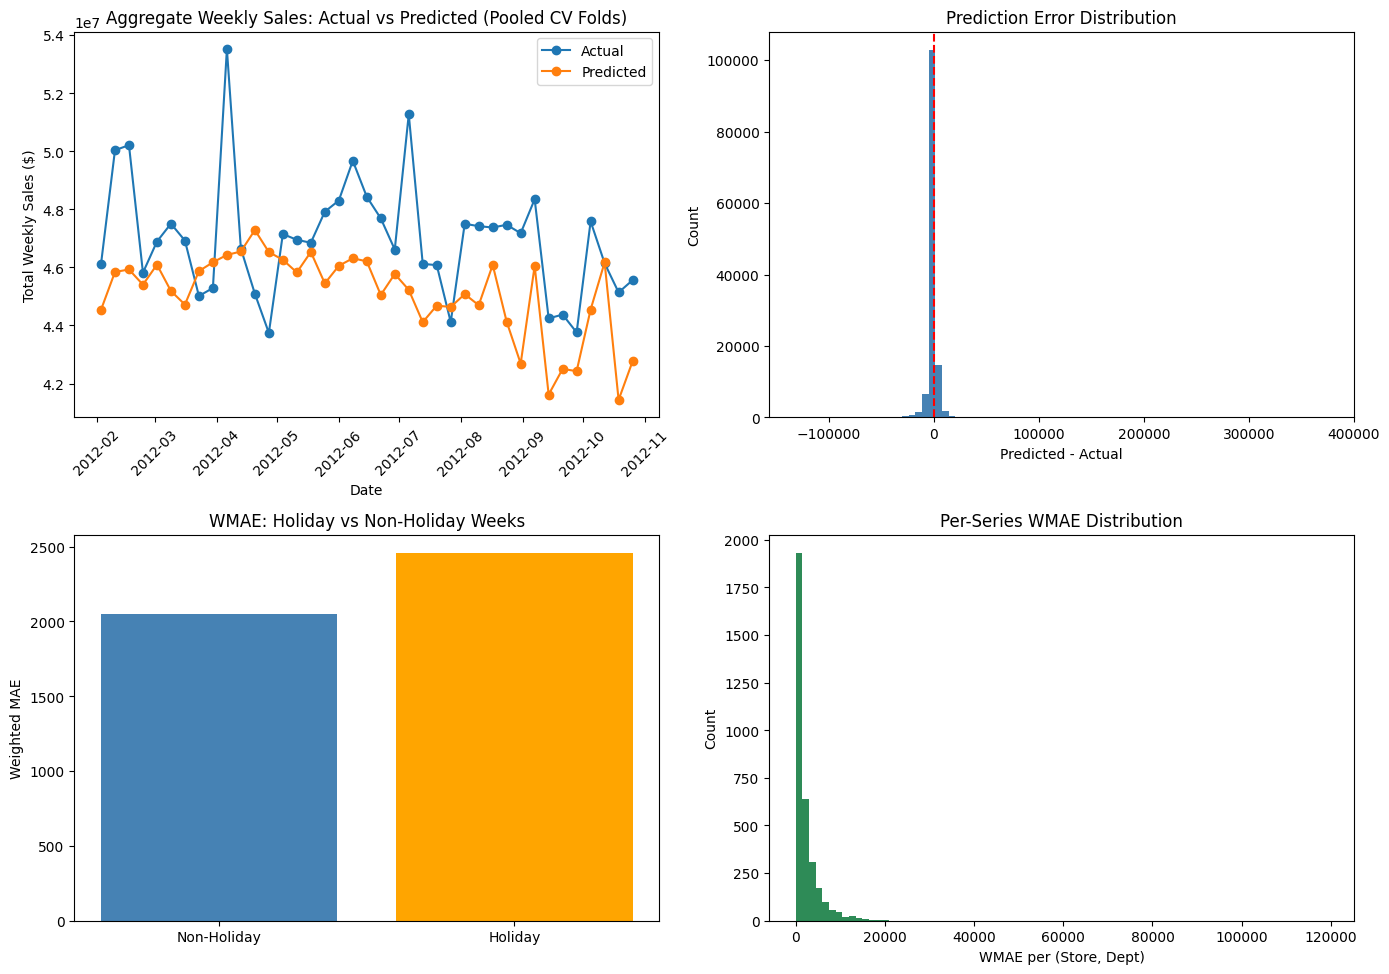

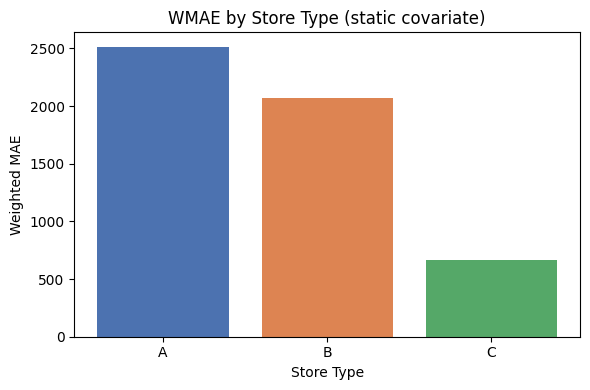

Top 10 worst-performing series (highest WMAE):
Store  Dept
9      77      119209.566013
10     3        28808.001888
14     92       26316.934661
10     72       23890.096782
28     92       23572.599651
19     72       21192.032877
20     72       20479.489638
35     72       19714.046094
20     92       18537.247287
16     9        18219.840717
dtype: float64

WMAE by store Type:
Type
A    2514.008224
B    2068.898317
C     663.078313
dtype: float64


In [16]:
scored["error"] = scored["Weekly_Sales_Pred"] - scored["Weekly_Sales"]
scored["abs_error"] = scored["error"].abs()
scored["weight"] = scored["IsHoliday"].map({True: 5, False: 1})
scored = scored.merge(stores_df[["Store", "Type"]], on="Store", how="left")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

agg = scored.groupby("ds")[["Weekly_Sales", "Weekly_Sales_Pred"]].sum().sort_index()
axes[0, 0].plot(agg.index, agg["Weekly_Sales"], label="Actual", marker="o")
axes[0, 0].plot(agg.index, agg["Weekly_Sales_Pred"], label="Predicted", marker="o")
axes[0, 0].set_title("Aggregate Weekly Sales: Actual vs Predicted (Pooled CV Folds)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Total Weekly Sales ($)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].hist(scored["error"], bins=80, color="steelblue")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Prediction Error Distribution")
axes[0, 1].set_xlabel("Predicted - Actual")
axes[0, 1].set_ylabel("Count")

by_holiday = scored.groupby("IsHoliday")[["abs_error", "weight"]].apply(
    lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum()
)
axes[1, 0].bar(["Non-Holiday", "Holiday"], by_holiday.values, color=["steelblue", "orange"])
axes[1, 0].set_title("WMAE: Holiday vs Non-Holiday Weeks")
axes[1, 0].set_ylabel("Weighted MAE")


def series_wmae(g):
    w = g["IsHoliday"].map({True: 5, False: 1})
    return (g["abs_error"] * w).sum() / w.sum()


per_series = scored.groupby(["Store", "Dept"])[["IsHoliday", "abs_error"]].apply(series_wmae).sort_values(ascending=False)
axes[1, 1].hist(per_series, bins=80, color="seagreen")
axes[1, 1].set_title("Per-Series WMAE Distribution")
axes[1, 1].set_xlabel("WMAE per (Store, Dept)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../submissions/_nbeats_diagnostics.png", dpi=120)
plt.show()

by_type = scored.groupby("Type")[["abs_error", "weight"]].apply(
    lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum()
).sort_index()

plt.figure(figsize=(6, 4))
plt.bar(by_type.index.astype(str), by_type.values, color=["#4c72b0", "#dd8452", "#55a868"])
plt.title("WMAE by Store Type (static covariate)")
plt.xlabel("Store Type")
plt.ylabel("Weighted MAE")
plt.tight_layout()
plt.savefig("../submissions/_nbeats_wmae_by_type.png", dpi=120)
plt.show()

print("Top 10 worst-performing series (highest WMAE):")
print(per_series.head(10))
print("\nWMAE by store Type:")
print(by_type)


##  Representative-series forecast plots with quantile bands

Best- and worst-WMAE series from the diagnostics above, each showing
history, actual, the median forecast, and the 10-90% quantile band from the
probabilistic NBEATSx output. Also a direct visual check on whether the
future-covariate access fixed the old Darts N-BEATS's documented phase-shift
bug (holiday peaks landing a week late).


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 4.2 M  | train
--------------------------------------------------------------
4.2 M     Trainable params
1.8 K     Non-trainable params
4.2 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

[NBEATSx] step 2475/2500 - 99% (bound by step budget) - elapsed 71s, ~0.0 min remaining


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2500` reached.
/usr/local/lib/python3.12/dist-packages/neuralforecast/core.py:1222: UserWarning: Dropped 74 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
INFO:pytorch_lightning.utilities.rank_zero:Ignoring `Trainer(max_time=...)`, callbacks list already contains a Timer.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecat

Predicting: |          | 0/? [00:00<?, ?it/s]

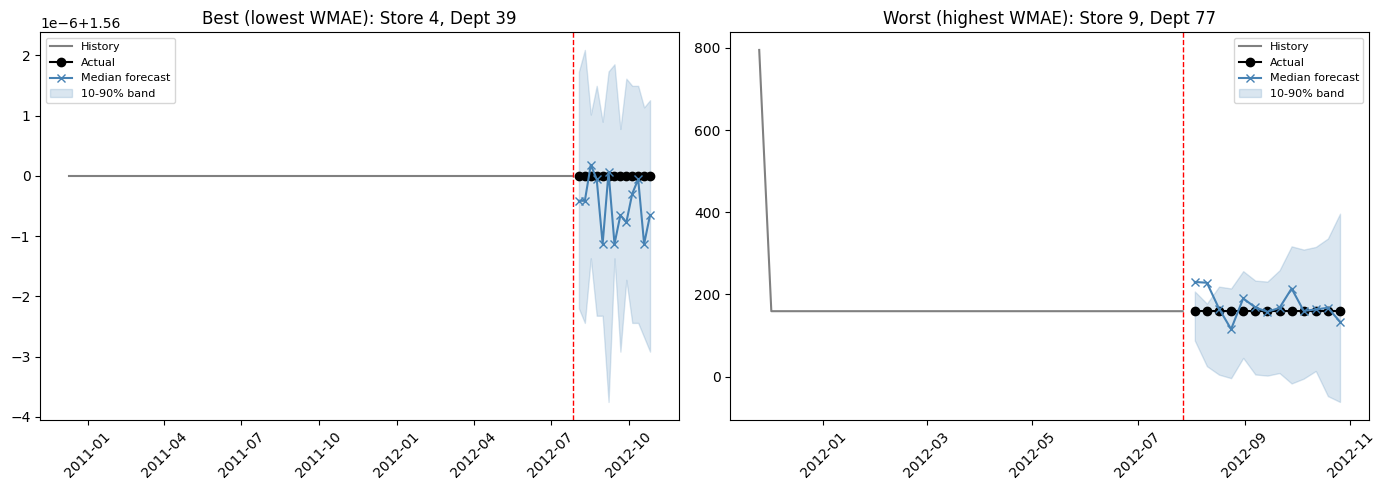

In [17]:
def plot_series_forecast(store, dept, split, ax, title_prefix):
    uid = f"{store}_{dept}"
    _, _, fold_scored, _, nf_fold = fit_predict_fold(
        split, max_steps=CV_MAX_STEPS, max_time_minutes=CV_MAX_TIME_MINUTES,
        batch_size=BATCH_SIZE_SEARCH, **BEST_HP_KWARGS
    )

    hist_df = panel_df.loc[(panel_df["unique_id"] == uid) & (panel_df["ds"] <= split.train_end)]
    series_scored = fold_scored.loc[fold_scored["unique_id"] == uid].sort_values("ds")

    lo_col = [c for c in series_scored.columns if c.endswith("-lo-80.0")]
    hi_col = [c for c in series_scored.columns if c.endswith("-hi-80.0")]

    ax.plot(hist_df["ds"], hist_df["y"], color="gray", label="History")
    ax.plot(series_scored["ds"], series_scored["Weekly_Sales"], color="black", marker="o", label="Actual")
    ax.plot(series_scored["ds"], series_scored["Weekly_Sales_Pred"], color="steelblue", marker="x", label="Median forecast")
    if lo_col and hi_col:
        ax.fill_between(
            series_scored["ds"], series_scored[lo_col[0]], series_scored[hi_col[0]],
            color="steelblue", alpha=0.2, label="10-90% band",
        )
    ax.axvline(split.train_end, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix}: Store {store}, Dept {dept}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)


best_key = per_series.index[-1]
worst_key = per_series.index[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_series_forecast(best_key[0], best_key[1], splits[-1], axes[0], "Best (lowest WMAE)")
plot_series_forecast(worst_key[0], worst_key[1], splits[-1], axes[1], "Worst (highest WMAE)")
plt.tight_layout()
plt.savefig("../submissions/_nbeats_representative_forecasts.png", dpi=120)
plt.show()


##  Required `.predict()` wrapper (`NBeatsXForecastPipeline`)

Every model needs a pipeline-shaped wrapper that takes raw, unpreprocessed
`test.csv`-shaped data and handles everything internally, so
`model_inference.ipynb` can call it directly. Contract is identical to the
TFT notebook's `NeuralForecastPipeline`: raw test df in,
`DataFrame[Id, Weekly_Sales]` out.


In [18]:
class NBeatsXForecastPipeline:
    def __init__(self, nf_model, preprocessor, df_scaler, numeric_cols,
                 future_covariate_cols, static_df, train_history_df,
                 freq="W-FRI"):
        self.nf_model = nf_model
        self.preprocessor = preprocessor
        self.df_scaler = df_scaler
        self.numeric_cols = numeric_cols
        self.future_covariate_cols = future_covariate_cols
        self.static_df = static_df
        self.train_history_df = train_history_df
        self.freq = freq

    def predict(self, raw_test_df):
        test_clean = self.preprocessor.transform(raw_test_df)
        test_feat_local = add_temporal_features(test_clean)

        futr_local = test_feat_local.copy()
        futr_local["unique_id"] = futr_local["Store"].astype(str) + "_" + futr_local["Dept"].astype(str)
        futr_local["ds"] = futr_local["Date"]
        futr_local[self.numeric_cols] = self.df_scaler.transform(futr_local[self.numeric_cols])

        # neuralforecast expects a futr_df row for EVERY (unique_id, ds) it forecasts
        # for every series the model was fit on - not just whatever combos happen to
        # appear in raw test.csv. A (Store, Dept) that stopped selling and is genuinely
        # absent from test.csv (a real, known quirk of this dataset) would otherwise be
        # missing entirely from futr_df and crash nf.predict() with "missing combinations
        # of ids and times in futr_df". Build a full (fitted unique_id) x (test date)
        # grid instead, and fill it from a Store-level covariate lookup (covariates don't
        # vary by Dept, so any Store present in test_feat_local covers all its Depts,
        # fitted or not) - any resulting extra rows beyond what Kaggle needs are dropped
        # by the submission-reconciliation step below, same as always.
        test_dates = pd.to_datetime(sorted(test_feat_local["Date"].unique()))
        store_cov = build_covariate_lookup(
            futr_local, self.future_covariate_cols,
            test_dates.min(), test_dates.max(), freq=self.freq,
        )

        fitted_uids = self.static_df[["unique_id"]].copy()
        fitted_uids["Store"] = fitted_uids["unique_id"].str.split("_", n=1).str[0].astype(int)

        futr_df = (
            fitted_uids.merge(pd.DataFrame({"ds": test_dates}), how="cross")
            .merge(store_cov, on=["Store", "ds"], how="left")
        )
        missing = futr_df[self.future_covariate_cols].isna().any(axis=1).sum()
        assert missing == 0, f"{missing} futr_df rows missing future-covariate values after Store-level lookup"
        futr_df = futr_df[["unique_id", "ds"] + self.future_covariate_cols]

        preds = self.nf_model.predict(futr_df=futr_df)
        med_col = median_column(preds)
        preds = preds.rename(columns={med_col: "Weekly_Sales"})

        ids = preds["unique_id"].str.split("_", n=1, expand=True)
        preds["Store"] = ids[0].astype(int)
        preds["Dept"] = ids[1].astype(int)
        preds["Id"] = (
            preds["Store"].astype(str) + "_" +
            preds["Dept"].astype(str) + "_" +
            preds["ds"].dt.strftime("%Y-%m-%d")
        )
        return preds[["Id", "Weekly_Sales"]]


##  Final fit on full history and log `NBEATS_Final`

Refits on all available train data with a fresh model instance, using
`BEST_HP_KWARGS` from the hyperparameter search and `h=HORIZON` (39, the
full test horizon - CV/HP folds only forecast 13 weeks), bounded by
`FINAL_MAX_TIME_MINUTES`. `start_padding_enabled=True` means no series needs
to be dropped for insufficient history. Wraps the fitted model, and logs the
wrapper (not the bare model) as the run artifact so `model_inference.ipynb`
can load it directly. A training-loss curve is logged as an artifact on this
run too.


In [19]:
final_csv_logger = CSVLogger(save_dir="../submissions/_nbeats_logs", name="final")

final_model = NBEATSx(
    h=HORIZON,
    input_size=INPUT_SIZE,
    stat_exog_list=STATIC_COLS,
    hist_exog_list=PAST_COVARIATE_COLS,
    futr_exog_list=FUTURE_COVARIATE_COLS,
    loss=MQLoss(quantiles=QUANTILES),
    max_steps=FINAL_MAX_STEPS,
    batch_size=BATCH_SIZE_FINAL,
    scaler_type="robust",
    random_seed=42,
    start_padding_enabled=True,
    **BEST_HP_KWARGS,
    **make_trainer_kwargs(logger=final_csv_logger, max_time_minutes=FINAL_MAX_TIME_MINUTES),
)
final_nf = NeuralForecast(models=[final_model], freq=FREQ)

t0 = time.time()
final_nf.fit(
    df=panel_df[["unique_id", "ds", "y"] + PAST_COVARIATE_COLS + FUTURE_COVARIATE_COLS],
    static_df=static_df,
)
final_fit_seconds = time.time() - t0
print(f"Final fit took {final_fit_seconds:.1f}s over {panel_df['unique_id'].nunique()} series")

pipeline = NBeatsXForecastPipeline(
    nf_model=final_nf,
    preprocessor=preprocessor,
    df_scaler=df_scaler,
    numeric_cols=numeric_cols,
    future_covariate_cols=FUTURE_COVARIATE_COLS,
    static_df=static_df,
    train_history_df=train_feat,
    freq=FREQ,
)

with mlflow.start_run(run_name="NBEATS_Final") as final_run:
    mlflow.log_params({
        "library": "neuralforecast",
        "model": "NBEATSx",
        "max_steps": FINAL_MAX_STEPS,
        "max_time_minutes": FINAL_MAX_TIME_MINUTES,
        "batch_size": BATCH_SIZE_FINAL,
        "input_size": INPUT_SIZE,
        "horizon": HORIZON,
        "future_covariates": ",".join(FUTURE_COVARIATE_COLS) if FUTURE_COVARIATE_COLS else "none",
        "past_covariates": ",".join(PAST_COVARIATE_COLS),
        "static_covariates": ",".join(STATIC_COLS),
        "n_series_final": panel_df["unique_id"].nunique(),
        "cv_strategy": "expanding_window",
        "n_splits": N_SPLITS,
        "val_weeks": VAL_WEEKS,
        "stack_types": str(BEST_HP_KWARGS["stack_types"]),
        "n_blocks": str(BEST_HP_KWARGS["n_blocks"]),
    })
    mlflow.log_metric("cv_wmae_mean_at_selection", wmae_mean)
    mlflow.log_metric("cv_wmae_std_at_selection", wmae_std)
    mlflow.log_metric("cv_mae_mean_at_selection", mae_mean)
    mlflow.log_metric("final_fit_seconds", final_fit_seconds)

    try:
        final_loss_history = pd.read_csv(latest_metrics_csv(final_csv_logger))
        loss_col = "train_loss_epoch" if "train_loss_epoch" in final_loss_history else "train_loss"
        loss_curve = final_loss_history.dropna(subset=[loss_col]) if loss_col in final_loss_history else None
        plt.figure(figsize=(6, 4))
        if loss_curve is not None and not loss_curve.empty:
            plt.plot(loss_curve["step"], loss_curve[loss_col], marker="o", color="darkorange")
        plt.title("NBEATSx Final - training loss")
        plt.xlabel("Step")
        plt.ylabel("Train loss")
        plt.tight_layout()
        plt.savefig("../submissions/_nbeats_final_train_loss.png", dpi=120)
        plt.close()
        mlflow.log_artifact("../submissions/_nbeats_final_train_loss.png")
    except Exception as e:
        print(f"Could not read/plot final loss history ({e})")

    with tempfile.TemporaryDirectory() as tmp:
        pkl_path = f"{tmp}/nbeats_pipeline.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(pipeline, f)
        mlflow.log_artifact(pkl_path, artifact_path="pipeline")

    final_run_id = final_run.info.run_id

print("Logged NBEATS_Final wrapper artifact, run_id:", final_run_id)


INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MQLoss        | 3      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 5.0 M  | train
--------------------------------------------------------------
5.0 M     Trainable params
7.2 K     Non-trainable params
5.0 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

[NBEATSx] step 9900/10000 - 99% (bound by step budget) - elapsed 440s, ~0.1 min remaining


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=10000` reached.


Final fit took 445.1s over 3331 series
🏃 View run NBEATS_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2/runs/ec9c62da93e14fdcbfe8f1659471ed75
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2
Logged NBEATS_Final wrapper artifact, run_id: ec9c62da93e14fdcbfe8f1659471ed75


##  Generate submission CSV

Reconciles against `sampleSubmission.csv` exactly - drops any predicted rows
beyond what's required, fills any missing ones (series `neuralforecast` had
no history for at all) with a store/dept mean fallback, so the row count and
ID set match precisely. Also pushes the submission CSV and the diagnostics
PNGs to MLflow as artifacts on `NBEATS_Final`.


In [20]:
submission = pipeline.predict(test_raw)

sample = pd.read_csv("../data/raw/sampleSubmission.csv")
required_ids = set(sample["Id"])

extra_ids = set(submission["Id"]) - required_ids
print("Extra rows generated beyond what's needed:", len(extra_ids))

submission_filtered = submission[submission["Id"].isin(required_ids)].copy()
missing_ids = required_ids - set(submission_filtered["Id"])
print("Still missing after filtering:", len(missing_ids))

fallback_lookup = train_feat.groupby(["Store", "Dept"])["Weekly_Sales"].mean().to_dict()
global_fallback = train_feat["Weekly_Sales"].mean()

missing_df = pd.DataFrame({"Id": sorted(missing_ids)})
parts = missing_df["Id"].str.rsplit("_", n=1, expand=True)
store_dept = parts[0].str.split("_", n=1, expand=True)
missing_df["Store"] = store_dept[0].astype(int)
missing_df["Dept"] = store_dept[1].astype(int)
missing_df["Weekly_Sales"] = missing_df.apply(
    lambda r: fallback_lookup.get((r["Store"], r["Dept"]), global_fallback), axis=1
)

final_submission = pd.concat(
    [submission_filtered, missing_df[["Id", "Weekly_Sales"]]], ignore_index=True
).sort_values("Id").reset_index(drop=True)

print("Final rows:", len(final_submission), "| Expected:", len(sample))
assert len(final_submission) == len(sample)
assert set(final_submission["Id"]) == required_ids

final_submission.to_csv("../submissions/nbeats_submission.csv", index=False)
final_submission.head()


/usr/local/lib/python3.12/dist-packages/neuralforecast/core.py:1222: UserWarning: Dropped 429 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
INFO:pytorch_lightning.utilities.rank_zero:Ignoring `Trainer(max_time=...)`, callbacks list already contains a Timer.
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Extra rows generated beyond what's needed: 14881
Still missing after filtering: 36
Final rows: 115064 | Expected: 115064


,Id,Weekly_Sales
0,10_10_2012-11-02,43604.769531
1,10_10_2012-11-09,43614.121094
2,10_10_2012-11-16,43624.613281
3,10_10_2012-11-23,43634.699219
4,10_10_2012-11-30,43657.566406


In [21]:
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("../submissions/nbeats_submission.csv")
    mlflow.log_artifact("../submissions/_nbeats_diagnostics.png")
    mlflow.log_artifact("../submissions/_nbeats_wmae_by_type.png")
    mlflow.log_artifact("../submissions/_nbeats_representative_forecasts.png")

print("Submission + diagnostics logged as artifacts on NBEATS_Final (run_id:", final_run_id, ")")


🏃 View run NBEATS_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2/runs/ec9c62da93e14fdcbfe8f1659471ed75
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/2
Submission + diagnostics logged as artifacts on NBEATS_Final (run_id: ec9c62da93e14fdcbfe8f1659471ed75 )
